In [1]:
#Algorithm - Moving Average (MA)

In [2]:
#1.IMPORTING PANDAS LIBRARY
import pandas as pd

# import → Python keyword used to bring in a library/module
# pandas → open-source library for data manipulation and analysis
# as → keyword used to assign an alias (short name)
# pd → alias used to refer to pandas throughout the code

# Summary: This line imports the pandas library and gives it the shorter name "pd" for easy use later in the notebook.

In [3]:
#2.IMPORTING NSEPY AND DATETIME LIBRARIES

from nsepy import get_history as gh
# from → keyword used to import a specific part of a module
# nsepy → library used to fetch historical stock data from NSE (India)
# import → keyword used to bring in a library/module/function
# get_history → function used to fetch historical stock price data
# as → keyword used to assign an alias (short name)
# gh → alias used to refer to get_history function

import datetime as dt
# import → keyword used to bring in a library/module
# datetime → built-in module used to work with dates and times
# as → keyword used to assign an alias (short name)
# dt → alias used to refer to datetime module

# Summary: This line imports the get_history function from nsepy (renamed as gh) to fetch stock data, and the datetime module (renamed as dt) 
# to handle date values.

In [9]:
#3.FETCHING STOCK DATA USING YFINANCE

import yfinance as yf
# import → keyword used to bring in a library/module
# yfinance → library used to fetch stock market data from Yahoo Finance
# as → keyword used to assign an alias (short name)
# yf → alias used to refer to yfinance library

stk_data = yf.download("TCS.NS", start='2021-06-01', end='2022-01-28')
# stk_data → variable to store the fetched stock data
# yf.download → function used to download historical stock data
# "TCS.NS" → stock symbol for TCS (.NS suffix required for NSE stocks on Yahoo Finance)
# start → parameter specifying the start date (as string 'YYYY-MM-DD')
# end → parameter specifying the end date (as string 'YYYY-MM-DD')

# Summary: This line imports yfinance and fetches historical stock data for TCS.NS between the given dates, storing it in stk_data.

[*********************100%***********************]  1 of 1 completed


In [10]:
#4.SELECTING REQUIRED COLUMNS FROM STOCK DATA

stk_data = stk_data[["Open","High","Low","Close"]]
# stk_data → variable holding the stock data DataFrame
# [["Open","High","Low","Close"]] → selects only these specific columns from the DataFrame
# "Open" → opening price of the stock for each day
# "High" → highest price of the stock for each day
# "Low" → lowest price of the stock for each day
# "Close" → closing price of the stock for each day

#stk_data.to_csv("Tatacoffee13_21.csv")
# stk_data.to_csv → function used to save the DataFrame as a CSV file (currently commented out)
# "Tatacoffee13_21.csv" → filename for the exported CSV file

# Summary: This line filters stk_data to keep only the Open, High, Low, and Close columns, with an optional (commented-out) line to export the data 
# as a CSV file.

In [11]:
#5.SETTING TARGET COLUMN

column = "Close"
# column → variable to store the name of the target column
# "Close" → the closing price column, commonly used for analysis and forecasting

# Summary: This line defines a variable "column" set to "Close", specifying which column will be used for further analysis.column="Close"

In [12]:
#6.SCALING THE TARGET COLUMN USING MINMAXSCALER

from sklearn.preprocessing import MinMaxScaler
# from → keyword used to import a specific part of a module
# sklearn.preprocessing → module containing data preprocessing tools
# import → keyword used to bring in a library/module/function
# MinMaxScaler → class used to scale features to a fixed range (default 0 to 1)

Ms = MinMaxScaler()
# Ms → variable to store the MinMaxScaler object
# MinMaxScaler() → creates an instance of the scaler

data1 = Ms.fit_transform(stk_data[[column]])
# data1 → variable to store the scaled data
# Ms.fit_transform → function that fits the scaler to the data and transforms it
# stk_data[[column]] → selects the target column ("Close") as a DataFrame

print("Len:", data1.shape)
# print → built-in function to display output
# "Len:" → label text for the printed output
# data1.shape → returns the dimensions (rows, columns) of the scaled data

# Summary: This line scales the "Close" column values between 0 and 1 using MinMaxScaler and prints the shape of the resulting scaled data.

Len: (166, 1)


In [13]:
#7.SPLITTING DATA INTO TRAINING AND TESTING SETS

training_size = round(len(data1) * 0.95)
# training_size → variable to store the number of rows for training
# round → built-in function to round a number to the nearest integer
# len(data1) → returns the total number of rows in data1
# 0.95 → 95% of the data is allocated for training

print(training_size)
# print → built-in function to display output
# training_size → displays the calculated training size

X_train = data1[:training_size]
# X_train → variable to store the training input data
# data1[:training_size] → selects rows from the start up to training_size

X_test = data1[training_size:]
# X_test → variable to store the testing input data
# data1[training_size:] → selects rows from training_size to the end

print("X_train length:", X_train.shape)
# print → displays the shape (dimensions) of X_train

print("X_test length:", X_test.shape)
# print → displays the shape (dimensions) of X_test

y_train = data1[:training_size]
# y_train → variable to store the training target data
# data1[:training_size] → selects rows from the start up to training_size

y_test = data1[training_size:]
# y_test → variable to store the testing target data
# data1[training_size:] → selects rows from training_size to the end

print("y_train length:", y_train.shape)
# print → displays the shape (dimensions) of y_train

print("y_test length:", y_test.shape)
# print → displays the shape (dimensions) of y_test

# Summary: This line splits the scaled data into training (95%) and testing (5%) sets for both X and y, and prints their respective shapes.

158
X_train length: (158, 1)
X_test length: (8, 1)
y_train length: (158, 1)
y_test length: (8, 1)


In [14]:
#8.SUPPRESSING WARNINGS

import warnings
# import → keyword used to bring in a library/module
# warnings → built-in module used to control warning messages

warnings.filterwarnings("ignore")
# warnings.filterwarnings → function used to control how warnings are displayed
# "ignore" → setting that suppresses all warning messages

# Summary: This line imports the warnings module and disables all warning messages from being displayed in the notebook.

In [15]:
#9.TRAINING ARIMA MODEL WITH DIFFERENT TRENDS

from sklearn.metrics import mean_squared_error
# from → keyword used to import a specific part of a module
# sklearn.metrics → module containing performance evaluation metrics
# import → keyword used to bring in a library/module/function
# mean_squared_error → function used to calculate mean squared error (MSE)

trends = ['n','t','c','ct']
# trends → variable storing a list of trend types to test
# 'n' → no trend, 't' → time trend, 'c' → constant, 'ct' → constant + time trend

orders = [(0,0,1),(0,0,2)]
# orders → variable storing a list of ARIMA order combinations (currently unused in loop below)
# (p,d,q) → p=autoregressive terms, d=differencing, q=moving average terms

from statsmodels.tsa.arima.model import ARIMA
# from → keyword used to import a specific part of a module
# statsmodels.tsa.arima.model → module containing ARIMA modeling tools
# ARIMA → class used to build AutoRegressive Integrated Moving Average models

for td in trends:
# for → keyword used to start a loop
# td → loop variable representing each trend type
# in trends → iterates through the trends list

    model = ARIMA(X_train, order=(0,0,10), trend=td,)
    # model → variable to store the ARIMA model object
    # ARIMA → class used to create the model
    # X_train → training data used to fit the model
    # order=(0,0,10) → ARIMA order (p=0, d=0, q=10)
    # trend → trend type from the current loop iteration

    model_fit = model.fit()
    # model_fit → variable to store the fitted model
    # model.fit() → function that trains the ARIMA model on X_train

    # make prediction
    y_pred = model_fit.predict(len(X_train), len(data1)-1)
    # y_pred → variable to store predicted values
    # model_fit.predict → function used to generate predictions
    # len(X_train) → starting index for prediction (start of test period)
    # len(data1)-1 → ending index for prediction (end of full dataset)

    from sklearn.metrics import r2_score
    # from → keyword used to import a specific part of a module
    # sklearn.metrics → module containing evaluation metrics
    # r2_score → function used to calculate R-squared score

    mse = mean_squared_error(y_test, y_pred, squared=False)
    # mse → variable to store the error value (actually RMSE, since squared=False)
    # mean_squared_error → function used to compute the error
    # y_test → actual values
    # y_pred → predicted values
    # squared=False → returns RMSE instead of MSE

    from stockFunctions import rmsemape
    # from → keyword used to import a specific part of a module
    # stockFunctions → custom user-defined module
    # rmsemape → custom function used to calculate RMSE and MAPE

    print("Trend={}".format(td))
    # print → built-in function to display output
    # "Trend={}".format(td) → displays the current trend type being tested

    rmsemape(y_test, y_pred)
    # rmsemape → calls the custom function to print RMSE and MAPE for this trend

    print("************")
    # print → built-in function to display output
    # "************" → separator line for readability between trend results

# Summary: This loop trains an ARIMA model with order (0,0,10) for each trend type ('n','t','c','ct'), predicts on test data, and prints 
# the RMSE/MAPE performance metrics for comparison.

C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Trend=n
RMSE-Testset: 0.24355233791349665
maPe-Testset: 0.26675292247383425
************


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Trend=t
RMSE-Testset: 0.17244230778002434
maPe-Testset: 0.2009142075932301
************


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Trend=c
RMSE-Testset: 0.0780752752570316
maPe-Testset: 0.07964104215692035
************
Trend=ct
RMSE-Testset: 0.14233544943366824
maPe-Testset: 0.1658639653819094
************


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [16]:
#10.CHECKING LENGTH OF PREDICTIONS

len(y_pred)
# len → built-in function used to return the number of items in an object
# y_pred → variable holding the predicted values from the ARIMA model

# Summary: This line checks and returns the number of predicted values stored in y_pred.

8

In [17]:
#11.TRAINING ARIMA MODEL WITH TREND='c' AND ORDER (0,0,30)

#i=1
# i=1 → commented-out counter variable (currently unused)

td = "c"
# td → variable to store the trend type
# "c" → constant trend

model = ARIMA(X_train, order=(0,0,30), trend=td)
# model → variable to store the ARIMA model object
# ARIMA → class used to create the model
# X_train → training data used to fit the model
# order=(0,0,30) → ARIMA order (p=0, d=0, q=30)
# trend=td → trend type set to constant ("c")

model_fit = model.fit()
# model_fit → variable to store the fitted model
# model.fit() → function that trains the ARIMA model on X_train

# make prediction
y_pred = model_fit.predict(len(X_train), len(data1)-1)
# y_pred → variable to store predicted values
# model_fit.predict → function used to generate predictions
# len(X_train) → starting index for prediction (start of test period)
# len(data1)-1 → ending index for prediction (end of full dataset)

#print(y_pred)
# print(y_pred) → commented-out line to display predicted values

from sklearn.metrics import r2_score
# from → keyword used to import a specific part of a module
# sklearn.metrics → module containing evaluation metrics
# r2_score → function used to calculate R-squared score

mse = mean_squared_error(y_test, y_pred, squared=False)
# mse → variable to store the error value (actually RMSE, since squared=False)
# mean_squared_error → function used to compute the error
# y_test → actual values
# y_pred → predicted values
# squared=False → returns RMSE instead of MSE

from stockFunctions import rmsemape
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# rmsemape → custom function used to calculate RMSE and MAPE

print("Trend={}".format(td))
# print → built-in function to display output
# "Trend={}".format(td) → displays the current trend type

rmsemape(y_test, y_pred)
# rmsemape → calls the custom function to print RMSE and MAPE

print("************")
# print → built-in function to display output
# "************" → separator line for readability

# Summary: This block trains an ARIMA model with order (0,0,30) and trend='c', predicts on test data, and prints the RMSE/MAPE performance metrics.

C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Trend=c
RMSE-Testset: 0.14758892702770723
maPe-Testset: 0.17111942310640815
************


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


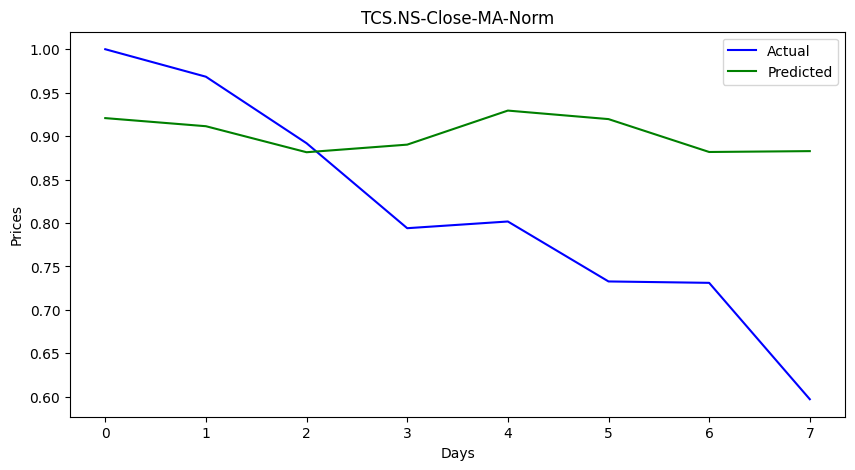

In [19]:
#12.PLOTTING ACTUAL VS PREDICTED VALUES

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(y_test, y_pred, "Actual", "Predicted", "TCS.NS-Close-MA-Norm", "Days", "Prices")
# graph → function call to generate the plot
# y_test → actual values to plot
# y_pred → predicted values to plot
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TCS.NS-Close-MA-Norm" → title of the graph
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices using the custom graph function, labeled with title and axis names.

In [20]:
#13.CHECKING LENGTH OF SCALED DATA

len(data1)
# len → built-in function used to return the number of items in an object
# data1 → variable holding the scaled "Close" price values

# Summary: This line checks and returns the total number of rows in the scaled dataset data1.

166

In [21]:
#14.CONVERTING TEST DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

aTestNormTable = conversionSingle(y_test, [column])
# aTestNormTable → variable to store the converted normalized test table
# conversionSingle → function call to reshape y_test into table format
# y_test → normalized actual test values
# [column] → column name list used as header ("Close")

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
# actual_stock_price_test_ori → variable to store the original-scale stock prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# aTestNormTable → normalized table to be converted back to original values

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])
# actual_stock_price_test_oriA → variable to store the final formatted original-scale prices
# conversionSingle → function call to reshape the data into table format again
# actual_stock_price_test_ori → original-scale stock price values
# [column] → column name list used as header ("Close")

# Summary: This block converts the normalized test values back to their original price scale using inverse_transform, then reformats 
# them into a table using conversionSingle.

In [22]:
#15.CONVERTING PREDICTED DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

pTestNormTable = conversionSingle(y_pred, [column])
# pTestNormTable → variable to store the converted normalized prediction table
# conversionSingle → function call to reshape y_pred into table format
# y_pred → normalized predicted values
# [column] → column name list used as header ("Close")

predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
# predicted_stock_price_test_ori → variable to store the original-scale predicted prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# pTestNormTable → normalized table to be converted back to original values

predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])
# predicted_stock_price_test_oriP → variable to store the final formatted original-scale predictions
# conversionSingle → function call to reshape the data into table format again
# predicted_stock_price_test_ori → original-scale predicted price values
# [column] → column name list used as header ("Close")

# Summary: This block converts the normalized predicted values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

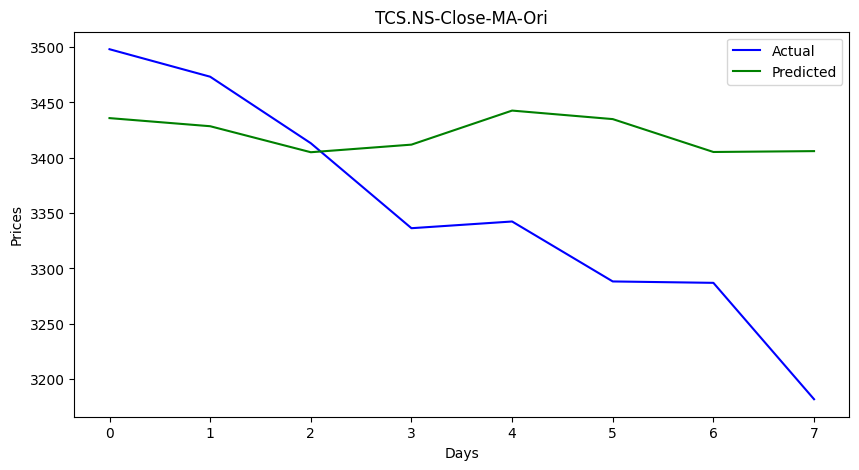

In [23]:
#16.PLOTTING ACTUAL VS PREDICTED VALUES (ORIGINAL SCALE)

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP, "Actual", "Predicted", "TCS.NS-Close-MA-Ori", "Days", "Prices")
# graph → function call to generate the plot
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TCS.NS-Close-MA-Ori" → title of the graph
# "Days" → label for the x-axis
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices in their original (unscaled) price values using the 
# custom graph function.

In [24]:
#17.CALCULATING RMSE AND MAPE (ORIGINAL SCALE)

from stockFunctions import rmsemape
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# rmsemape → custom function used to calculate RMSE and MAPE

rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)
# rmsemape → function call to compute and print error metrics
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale

# Summary: This line calculates and prints the RMSE and MAPE between actual and predicted stock prices in their original (unscaled) values.

RMSE-Testset: 115.93121027762264
maPe-Testset: 0.029600316552713023


In [25]:
#18.FORECASTING NEXT VALUE

forecast = model_fit.predict(len(data1), len(data1))
# forecast → variable to store the forecasted value
# model_fit.predict → function used to generate predictions from the fitted model
# len(data1) → starting index for forecast (one step beyond available data)
# len(data1) → ending index for forecast (single next value)

# Summary: This line uses the fitted ARIMA model to forecast the next value immediately following the available dataset.

In [26]:
#19.DISPLAYING FORECASTED VALUE

forecast
# forecast → variable holding the forecasted value from the ARIMA model

# Summary: This line displays the forecasted value generated by the ARIMA model.

array([0.89464412])

In [27]:
#20.CONVERTING FORECASTED VALUE BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

fTestNormTable = conversionSingle(forecast, ["Closefore"])
# fTestNormTable → variable to store the converted normalized forecast table
# conversionSingle → function call to reshape forecast into table format
# forecast → normalized forecasted value
# ["Closefore"] → column name list used as header for the forecast

forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
# forecast_stock_price_test_ori → variable to store the original-scale forecasted price
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# fTestNormTable → normalized table to be converted back to original values

forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])
# forecast_stock_price_test_oriF → variable to store the final formatted original-scale forecast
# conversionSingle → function call to reshape the data into table format again
# forecast_stock_price_test_ori → original-scale forecasted price value
# ["Closefore"] → column name list used as header for the forecast

# Summary: This block converts the normalized forecasted value back to its original price scale using inverse_transform, then reformats 
# it into a table using conversionSingle.

In [28]:
#21.DISPLAYING FORECASTED PRICE (ORIGINAL SCALE)

forecast_stock_price_test_oriF
# forecast_stock_price_test_oriF → variable holding the forecasted stock price converted back to its original scale

# Summary: This line displays the forecasted stock price after converting it back to its original (unscaled) value.

,Closefore
0,3415.372028


In [29]:
#22.SAVING FORECASTED PRICE TO CSV

forecast_stock_price_test_oriF.to_csv("CloseMA.csv", index=False)
# forecast_stock_price_test_oriF → variable holding the forecasted stock price (original scale)
# .to_csv → function used to export a DataFrame to a CSV file
# "CloseMA.csv" → filename for the exported CSV file
# index=False → excludes the DataFrame index from being written to the file

# Summary: This line saves the forecasted stock price to a CSV file named "CloseMA.csv", without including the row index.